In [1]:
import wrds
import pandas as pd
db = wrds.Connection(wrds_username='mainiyang')

Loading library list...
Done


In [2]:
tickers = ['WMT', 'COST', 'TGT', 'HD', 'AAPL', 'MSFT', 'GOOGL', 'KO', 'PEP', 'NKE']
start_year = 2018
end_year = 2024
tickers_str = "', '".join(tickers)

sql_query = f"""
SELECT tic, fyear, sale, at, lt, ceq, ni, act, lct
FROM comp.funda
WHERE tic IN ('{tickers_str}')
  AND fyear BETWEEN {start_year} AND {end_year}
  AND datafmt = 'STD'
  AND consol = 'C'
  AND indfmt = 'INDL'
"""

print(sql_query)


SELECT tic, fyear, sale, at, lt, ceq, ni, act, lct
FROM comp.funda
WHERE tic IN ('WMT', 'COST', 'TGT', 'HD', 'AAPL', 'MSFT', 'GOOGL', 'KO', 'PEP', 'NKE')
  AND fyear BETWEEN 2018 AND 2024
  AND datafmt = 'STD'
  AND consol = 'C'
  AND indfmt = 'INDL'



In [3]:
data = db.raw_sql(sql_query)
data

,tic,fyear,sale,at,lt,ceq,ni,act,lct
0,AAPL,2018,265359.0,365725.0,258578.0,107147.0,59531.0,131339.0,116866.0
1,AAPL,2019,260174.0,338516.0,248028.0,90488.0,55256.0,162819.0,105718.0
2,AAPL,2020,274515.0,323888.0,258549.0,65339.0,57411.0,143713.0,105392.0
3,AAPL,2021,365817.0,351002.0,287912.0,63090.0,94680.0,134836.0,125481.0
4,AAPL,2022,394328.0,352755.0,302083.0,50672.0,99803.0,135405.0,153982.0
...,...,...,...,...,...,...,...,...,...
65,WMT,2020,556933.0,252496.0,164965.0,80925.0,13510.0,90067.0,92645.0
66,WMT,2021,569962.0,244860.0,152969.0,83253.0,13673.0,81070.0,87379.0
67,WMT,2022,608481.0,243197.0,159206.0,76693.0,11680.0,75655.0,92198.0
68,WMT,2023,645737.0,252399.0,161828.0,83861.0,15511.0,76877.0,92415.0


In [4]:
db.close()

In [5]:
data.to_csv('company_financials.csv', index=False)
print('Data saved to company_financials.csv')
print(f'Rows: {len(data)}, Columns: {len(data.columns)}')

Data saved to company_financials.csv
Rows: 70, Columns: 9


## Data Cleaning

Raw data pulled from WRDS is not ready for analysis yet. Three things need to be done:

1. **Rename columns**: WRDS field names (`tic`, `sale`, `at`, etc.) are short but not intuitive. We rename them to more descriptive names.
2. **Check for missing values**: Some companies may have missing fields in certain years — we need to see the extent before deciding how to handle them.
3. **Check for outliers**: Rows where equity (`ceq`) or total assets (`at`) are negative or zero are not meaningful for ratio analysis and should be excluded.


In [6]:
# Rename columns for readability
data = data.rename(columns={
    'tic': 'ticker',
    'fyear': 'year',
    'sale': 'revenue',           # Total revenue / sales
    'at': 'total_assets',        # Total assets
    'lt': 'total_liabilities',   # Total liabilities
    'ceq': 'equity',             # Common shareholders' equity
    'ni': 'net_income',          # Net income
    'act': 'current_assets',     # Current assets
    'lct': 'current_liabilities' # Current liabilities
})

data.head()


,ticker,year,revenue,total_assets,total_liabilities,equity,net_income,current_assets,current_liabilities
0,AAPL,2018,265359.0,365725.0,258578.0,107147.0,59531.0,131339.0,116866.0
1,AAPL,2019,260174.0,338516.0,248028.0,90488.0,55256.0,162819.0,105718.0
2,AAPL,2020,274515.0,323888.0,258549.0,65339.0,57411.0,143713.0,105392.0
3,AAPL,2021,365817.0,351002.0,287912.0,63090.0,94680.0,134836.0,125481.0
4,AAPL,2022,394328.0,352755.0,302083.0,50672.0,99803.0,135405.0,153982.0


In [7]:
# Check how many non-null rows each column has
print('Total rows in data:', len(data))
print()
print('Non-null rows per column:')
for col in data.columns:
    non_null_count = data[data[col].notna()].shape[0]
    print(f'  {col}: {non_null_count}')

Total rows in data: 70

Non-null rows per column:
  ticker: 70
  year: 70
  revenue: 70
  total_assets: 70
  total_liabilities: 70
  equity: 70
  net_income: 70
  current_assets: 70
  current_liabilities: 70


In [8]:
# Check for outliers: negative equity, zero/negative total assets, zero/negative revenue
print('Rows with equity <= 0:', data[data['equity'] <= 0].shape[0])
print('Rows with total_assets <= 0:', data[data['total_assets'] <= 0].shape[0])
print('Rows with revenue <= 0:', data[data['revenue'] <= 0].shape[0])

Rows with equity <= 0: 3
Rows with total_assets <= 0: 0
Rows with revenue <= 0: 0


In [9]:
# Which company-years have negative equity?
data[data['equity'] <= 0]

,ticker,year,revenue,total_assets,total_liabilities,equity,net_income,current_assets,current_liabilities
21,HD,2018,108203.0,44003.0,45881.0,-1878.0,11121.0,18529.0,16716.0
22,HD,2019,110225.0,51236.0,54352.0,-3116.0,11242.0,19810.0,18375.0
24,HD,2021,151157.0,71876.0,73572.0,-1696.0,16433.0,29055.0,28693.0


### Data Cleaning Decisions

Total rows in `data`: 70. Check results:

- **Missing values: 0** — no action needed
- **Rows with total_assets ≤ 0: 0** — no outliers
- **Rows with revenue ≤ 0: 0** — no outliers
- **Rows with equity ≤ 0: 3** — Home Depot (HD) in 2018, 2019, and 2021

**Why is Home Depot's equity negative?**

Home Depot is one of the most famous examples in U.S. markets of a "share-buyback-driven" company. Over many years, it has used most of its earnings to repurchase its own shares. Cumulative buybacks have exceeded cumulative retained earnings, pushing book equity into negative territory. This does **not** reflect poor operating performance — Home Depot's net income, revenue, and total assets have all grown steadily over the same period.

**Why exclude these 3 rows?**

ROE = Net Income / Equity. When equity is negative, ROE turns into a negative number — but the meaning of that negative sign is completely different from "company lost money." **Including these rows would make the DuPont decomposition charts unreadable.** It also reminds us of an important point: financial ratio analysis cannot be separated from business context. The same formula applied to companies with different capital structures can give misleading results.

This observation is discussed further in the final reflection document.


In [10]:
# Exclude rows with equity <= 0 (Home Depot 2018 / 2019 / 2021)
data_clean = data[data['equity'] > 0].copy()

print(f'Before cleaning: {len(data)} rows')
print(f'After cleaning:  {len(data_clean)} rows')
print(f'Excluded:        {len(data) - len(data_clean)} rows')


Before cleaning: 70 rows
After cleaning:  67 rows
Excluded:        3 rows


## Computing the Five Financial Ratios

With clean data in hand, we now compute five core financial ratios. The first four are the building blocks of the DuPont decomposition. The fifth (current ratio) is an additional short-term liquidity indicator.

| Ratio | Formula | Business meaning |
|---|---|---|
| ROE (Return on Equity) | Net Income / Equity | How much return each dollar of shareholder equity generates |
| Profit Margin | Net Income / Revenue | How much of each dollar of sales becomes profit |
| Asset Turnover | Revenue / Total Assets | How much revenue each dollar of assets generates |
| Equity Multiplier | Total Assets / Equity | How much total assets a dollar of equity controls (a leverage measure) |
| Current Ratio | Current Assets / Current Liabilities | How many times short-term assets cover short-term liabilities |

**DuPont formula**: ROE = Profit Margin × Asset Turnover × Equity Multiplier

If we multiply the three factors together, the result should be **exactly equal** to the directly-computed ROE. We will verify this next.


In [11]:
# Compute the five financial ratios
data_clean['roe'] = data_clean['net_income'] / data_clean['equity']
data_clean['profit_margin'] = data_clean['net_income'] / data_clean['revenue']
data_clean['asset_turnover'] = data_clean['revenue'] / data_clean['total_assets']
data_clean['equity_multiplier'] = data_clean['total_assets'] / data_clean['equity']
data_clean['current_ratio'] = data_clean['current_assets'] / data_clean['current_liabilities']

data_clean.head()

,ticker,year,revenue,total_assets,total_liabilities,equity,net_income,current_assets,current_liabilities,roe,profit_margin,asset_turnover,equity_multiplier,current_ratio
0,AAPL,2018,265359.0,365725.0,258578.0,107147.0,59531.0,131339.0,116866.0,0.555601,0.224341,0.72557,3.413301,1.123843
1,AAPL,2019,260174.0,338516.0,248028.0,90488.0,55256.0,162819.0,105718.0,0.610645,0.212381,0.768572,3.741004,1.540126
2,AAPL,2020,274515.0,323888.0,258549.0,65339.0,57411.0,143713.0,105392.0,0.878664,0.209136,0.847562,4.957039,1.363604
3,AAPL,2021,365817.0,351002.0,287912.0,63090.0,94680.0,134836.0,125481.0,1.500713,0.258818,1.042208,5.563512,1.074553
4,AAPL,2022,394328.0,352755.0,302083.0,50672.0,99803.0,135405.0,153982.0,1.969589,0.253096,1.117852,6.961537,0.879356


### Verifying the DuPont Formula

The DuPont formula **ROE = Profit Margin × Asset Turnover × Equity Multiplier** is a mathematical identity (cancel the numerators and denominators and you get the definition of ROE). So the product of the three factors should equal the directly-computed ROE exactly.

Any difference between the two would indicate an error in one of the previous steps. This is a simple but important self-check.


In [12]:
# Verify ROE using the three-factor product
data_clean['roe_from_dupont'] = (
    data_clean['profit_margin'] *
    data_clean['asset_turnover'] *
    data_clean['equity_multiplier']
)

# Compute the difference
data_clean['roe_diff'] = data_clean['roe'] - data_clean['roe_from_dupont']

# Check min and max of the difference
print('Max of roe_diff:', data_clean['roe_diff'].max())
print('Min of roe_diff:', data_clean['roe_diff'].min())

Max of roe_diff: 1.7763568394002505e-15
Min of roe_diff: -4.440892098500626e-16


## Focus: Comparing the Big Three U.S. Retailers

So far we have clean financial data for 10 companies across 67 rows. The rest of the analysis focuses on three of them: **Walmart (WMT), Costco (COST), and Target (TGT)**.

### Why these three?

| Company | Ticker | Scale (FY2024 revenue) | Strategic positioning |
|---|---|---|---|
| Walmart | WMT | ~$678 B | World's largest retailer. Wins on scale — extremely low prices, thin margins, massive foot traffic |
| Costco | COST | ~$254 B | Membership warehouse retail. Part of revenue comes from membership fees; wins on "extreme turnover" |
| Target | TGT | ~$107 B | Mid-tier differentiated positioning. Emphasizes store experience and private-label brands; sits between the other two |

**What they have in common:**
- Same industry (general merchandise retail)
- Same country (U.S.)
- All are decades-old, mature companies

**What makes them different: their business models.**

If the textbook DuPont formula is genuinely useful, it should be able to cleanly decompose these three different "ways of making money." That is what we are about to verify.

### Analysis path

1. Compare the three companies' **ROE** first — we'll spot something interesting
2. Then the **DuPont three-factor decomposition** — look at the drivers behind ROE
3. Finally, connect these findings back to business models


In [13]:
# Filter to the three retailers
retail = data_clean[data_clean['ticker'].isin(['WMT', 'COST', 'TGT'])]
print(f'Three retailers: {len(retail)} rows total (3 companies x 7 years)')
retail

Three retailers: 21 rows total (3 companies x 7 years)


,ticker,year,revenue,total_assets,total_liabilities,equity,net_income,current_assets,current_liabilities,roe,profit_margin,asset_turnover,equity_multiplier,current_ratio,roe_from_dupont,roe_diff
7,COST,2018,141576.0,40830.0,27727.0,12799.0,3134.0,20289.0,19926.0,0.244863,0.022137,3.46745,3.190093,1.018217,0.244863,0.0
8,COST,2019,152703.0,45400.0,29816.0,15243.0,3659.0,23485.0,23237.0,0.240045,0.023962,3.363502,2.978416,1.010673,0.240045,-0.0
9,COST,2020,166761.0,55556.0,36851.0,18284.0,4002.0,28120.0,24844.0,0.21888,0.023998,3.001674,3.038504,1.131863,0.21888,-0.0
10,COST,2021,195929.0,59268.0,41190.0,17564.0,5007.0,29505.0,29441.0,0.285072,0.025555,3.305814,3.374402,1.002174,0.285072,0.0
11,COST,2022,226954.0,64166.0,43519.0,20642.0,5844.0,32696.0,31998.0,0.283112,0.02575,3.536982,3.108517,1.021814,0.283112,0.0
12,COST,2023,242290.0,68994.0,43936.0,25058.0,6292.0,35879.0,33583.0,0.251097,0.025969,3.511755,2.753372,1.068368,0.251097,0.0
13,COST,2024,254453.0,69831.0,46209.0,23622.0,7367.0,34246.0,35464.0,0.31187,0.028952,3.64384,2.956185,0.965655,0.31187,0.0
56,TGT,2018,75356.0,41290.0,29993.0,11297.0,2937.0,12519.0,15014.0,0.259981,0.038975,1.825042,3.654953,0.833822,0.259981,0.0
57,TGT,2019,78112.0,42779.0,30946.0,11833.0,3281.0,12902.0,14487.0,0.277275,0.042004,1.825943,3.615229,0.890592,0.277275,0.0
58,TGT,2020,93561.0,51248.0,36808.0,14440.0,4368.0,20756.0,20125.0,0.302493,0.046686,1.825652,3.54903,1.031354,0.302493,0.0


In [14]:
# Keep only the columns we need for comparison
retail_ratios = retail[['ticker', 'year', 'roe', 'profit_margin',
                         'asset_turnover', 'equity_multiplier', 'current_ratio']].copy()

# Convert ratios to percentages / rounded form for readability
retail_ratios_pct = retail_ratios.copy()
retail_ratios_pct['roe'] = (retail_ratios_pct['roe'] * 100).round(1)
retail_ratios_pct['profit_margin'] = (retail_ratios_pct['profit_margin'] * 100).round(1)
retail_ratios_pct['asset_turnover'] = retail_ratios_pct['asset_turnover'].round(2)
retail_ratios_pct['equity_multiplier'] = retail_ratios_pct['equity_multiplier'].round(2)
retail_ratios_pct['current_ratio'] = retail_ratios_pct['current_ratio'].round(2)

retail_ratios_pct



,ticker,year,roe,profit_margin,asset_turnover,equity_multiplier,current_ratio
7,COST,2018,24.5,2.2,3.47,3.19,1.02
8,COST,2019,24.0,2.4,3.36,2.98,1.01
9,COST,2020,21.9,2.4,3.0,3.04,1.13
10,COST,2021,28.5,2.6,3.31,3.37,1.0
11,COST,2022,28.3,2.6,3.54,3.11,1.02
12,COST,2023,25.1,2.6,3.51,2.75,1.07
13,COST,2024,31.2,2.9,3.64,2.96,0.97
56,TGT,2018,26.0,3.9,1.83,3.65,0.83
57,TGT,2019,27.7,4.2,1.83,3.62,0.89
58,TGT,2020,30.2,4.7,1.83,3.55,1.03


### Initial observation: the numbers already tell a story

Look at Costco vs. Target in 2018. The two companies have **almost identical ROE** (24.5% vs. 26.0%), but when we break the ROE apart, **their business models turn out to be the opposite of each other**:

- **Costco**: Profit margin only 2.2%, but asset turnover is 3.47 → sells cheap, turns over fast
- **Target**: Profit margin 3.9% (nearly 2x Costco), but turnover only 1.83 (less than half of Costco) → sells at higher margin, turns over slowly

**Roughly the same 25% ROE — but one gets there through turnover efficiency, the other through pricing power.** This is exactly what the DuPont decomposition is designed to reveal. Let's visualize this difference to make it more intuitive.


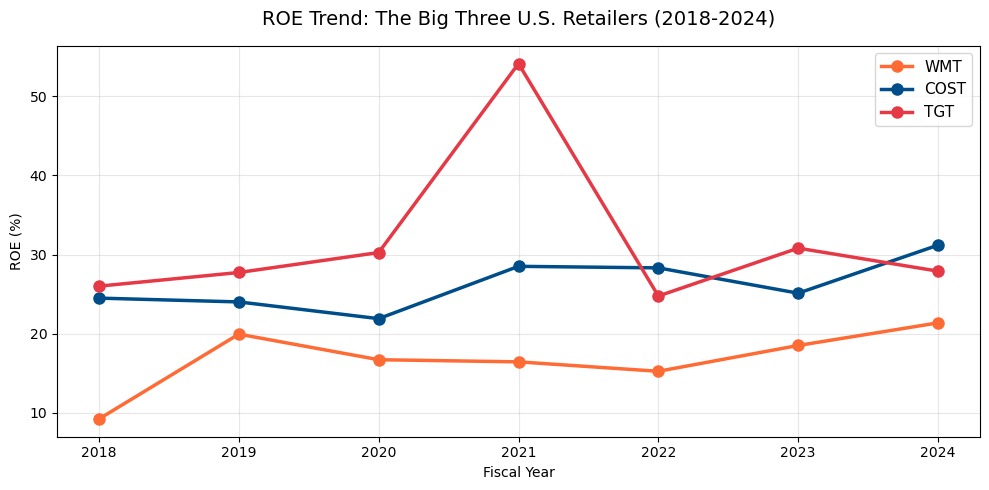

In [15]:
import matplotlib.pyplot as plt

# Font setup (works on macOS; harmless elsewhere)
plt.rcParams['axes.unicode_minus'] = False

# Plot the three retailers' ROE over time
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'WMT': '#FF6B35', 'COST': '#004E89', 'TGT': '#E63946'}

for ticker in ['WMT', 'COST', 'TGT']:
    company_data = retail[retail['ticker'] == ticker].sort_values('year')
    ax.plot(company_data['year'], company_data['roe'] * 100,
            marker='o', linewidth=2.5, markersize=8,
            label=ticker, color=colors[ticker])

ax.set_title('ROE Trend: The Big Three U.S. Retailers (2018-2024)', fontsize=14, pad=15)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('ROE (%)')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Beyond the level: how *stable* is each company's ROE?

A high ROE might look impressive, but a *volatile* ROE signals a riskier business. To measure stability, we compute the standard deviation of each company's ROE across the 7-year window. Low standard deviation = steady compounding; high standard deviation = big year-to-year swings.

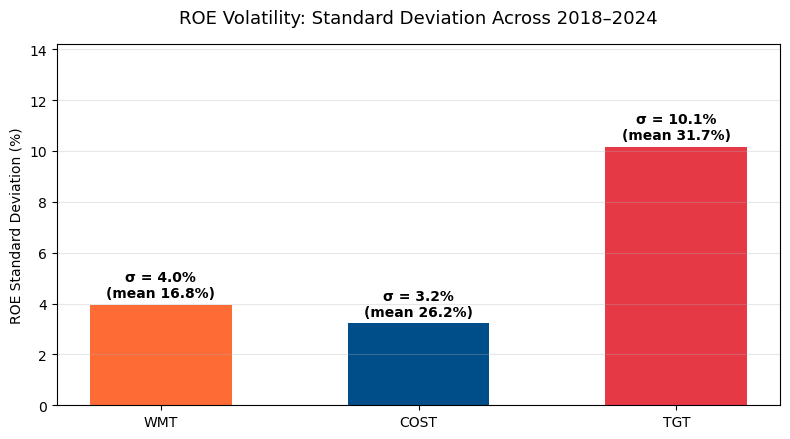


Interpretation:
- WMT: mean ROE 16.8% with σ = 4.0% (note: 2018 tax-reform anomaly inflates this)
- COST: mean ROE 26.2% with σ = 3.2% (steadiest)
- TGT: mean ROE 31.7% with σ = 10.1% (2021 pandemic spike drives volatility)


In [16]:
# Chart 8: ROE volatility comparison (standard deviation across years)
roe_stats = retail.groupby('ticker')['roe'].agg(['mean', 'std']).reindex(['WMT', 'COST', 'TGT'])
roe_stats['mean_pct'] = roe_stats['mean'] * 100
roe_stats['std_pct'] = roe_stats['std'] * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
colors_list = ['#FF6B35', '#004E89', '#E63946']

bars = ax.bar(roe_stats.index, roe_stats['std_pct'], color=colors_list, width=0.55)

for bar, val_std, val_mean in zip(bars, roe_stats['std_pct'], roe_stats['mean_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val_std + 0.3,
            f'\u03c3 = {val_std:.1f}%\n(mean {val_mean:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('ROE Volatility: Standard Deviation Across 2018\u20132024', fontsize=13, pad=15)
ax.set_ylabel('ROE Standard Deviation (%)')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(roe_stats['std_pct']) * 1.4)

plt.tight_layout()
plt.show()

print()
print('Interpretation:')
print(f'- WMT: mean ROE {roe_stats.loc["WMT", "mean_pct"]:.1f}% with \u03c3 = {roe_stats.loc["WMT", "std_pct"]:.1f}% (note: 2018 tax-reform anomaly inflates this)')
print(f'- COST: mean ROE {roe_stats.loc["COST", "mean_pct"]:.1f}% with \u03c3 = {roe_stats.loc["COST", "std_pct"]:.1f}% (steadiest)')
print(f'- TGT: mean ROE {roe_stats.loc["TGT", "mean_pct"]:.1f}% with \u03c3 = {roe_stats.loc["TGT", "std_pct"]:.1f}% (2021 pandemic spike drives volatility)')


In [17]:
# Drill into WMT alone to understand its ROE trajectory
retail_ratios_pct[retail_ratios_pct['ticker'] == 'WMT'].sort_values('year')



,ticker,year,roe,profit_margin,asset_turnover,equity_multiplier,current_ratio
63,WMT,2018,9.2,1.3,2.33,3.02,0.8
64,WMT,2019,19.9,2.9,2.2,3.17,0.79
65,WMT,2020,16.7,2.4,2.21,3.12,0.97
66,WMT,2021,16.4,2.4,2.33,2.94,0.93
67,WMT,2022,15.2,1.9,2.5,3.17,0.82
68,WMT,2023,18.5,2.4,2.56,3.01,0.83
69,WMT,2024,21.4,2.9,2.6,2.87,0.82


### WMT 2018 anomaly

Walmart's 2018 ROE was only 9.2%, and its profit margin was a mere 1.3% — significantly lower than later years (profit margin 2.4-2.9%, ROE 16-21%). Reviewing the company's annual report shows that this was driven by two one-time events:

1. **U.S. Tax Cuts and Jobs Act**: The tax reform passed in late 2017 forced Walmart to incur a one-time tax charge related to the repatriation of foreign cash and the revaluation of deferred tax items in fiscal year 2018.
2. **$16 billion acquisition of Flipkart** (an Indian e-commerce company): Integration costs and one-time losses weighed on the bottom line.

**Why keep this data point instead of removing it?**

This anomaly itself illustrates an important limitation of financial ratio analysis — **single-year ratios can be distorted by one-time events**. The right approach is to look at multi-year trends (e.g., 5-year averages) rather than drawing conclusions from a single year. Starting from 2019, Walmart's ROE returned to normal levels.

This is a textbook example of why financial analysis must be combined with business context rather than relying solely on the numbers.


### Event study: the COVID shock (2019 → 2021)

The 2020–2021 period is a natural experiment. All three retailers were hit by the same macro event — but reacted very differently. Comparing each factor *before* (2019) and *after* (2021) the shock tells us which business models were resilient and which were opportunistic.

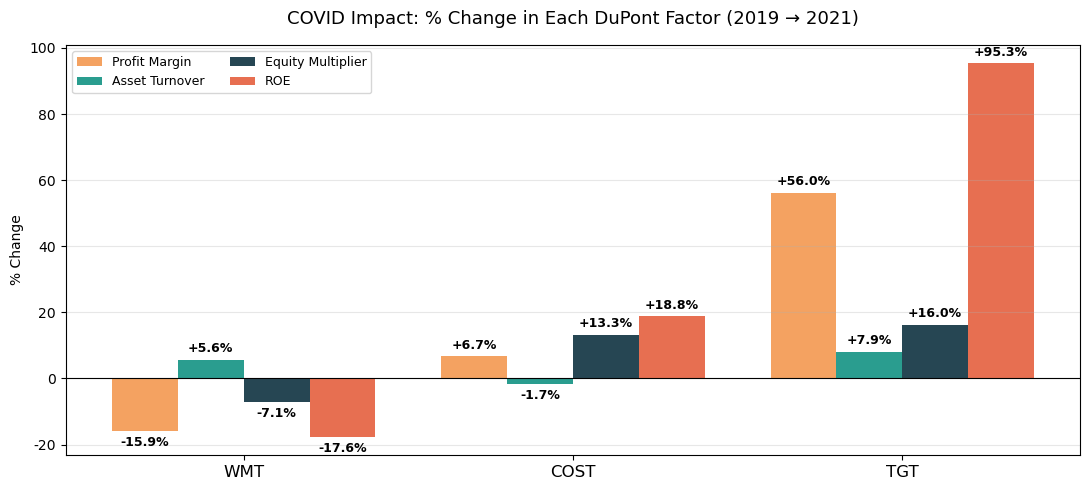

In [19]:
import numpy as np
# Chart 7: COVID shock \u2014 factor changes from 2019 (pre-pandemic) to 2021 (peak impact year)
pre = retail[retail['year'] == 2019].set_index('ticker')[['profit_margin', 'asset_turnover', 'equity_multiplier', 'roe']]
post = retail[retail['year'] == 2021].set_index('ticker')[['profit_margin', 'asset_turnover', 'equity_multiplier', 'roe']]

# Compute relative change (%)
changes = ((post - pre) / pre * 100).reindex(['WMT', 'COST', 'TGT'])

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(changes.index))
width = 0.2

metrics = [('profit_margin', 'Profit Margin', '#F4A261'),
           ('asset_turnover', 'Asset Turnover', '#2A9D8F'),
           ('equity_multiplier', 'Equity Multiplier', '#264653'),
           ('roe', 'ROE', '#E76F51')]

for i, (col, label, color) in enumerate(metrics):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, changes[col], width, label=label, color=color)
    for bar, val in zip(bars, changes[col]):
        va = 'bottom' if val >= 0 else 'top'
        offset_y = 1.5 if val >= 0 else -1.5
        ax.text(bar.get_x() + bar.get_width()/2, val + offset_y,
                f'{val:+.1f}%', ha='center', va=va, fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(changes.index, fontsize=12)
ax.set_title('COVID Impact: % Change in Each DuPont Factor (2019 \u2192 2021)', fontsize=13, pad=15)
ax.set_ylabel('% Change')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [20]:
import numpy as np

# Compute each company's 7-year averages for comparison
retail_avg = retail.groupby('ticker').agg({
    'profit_margin': 'mean',
    'asset_turnover': 'mean',
    'equity_multiplier': 'mean',
    'roe': 'mean'
}).reindex(['WMT', 'COST', 'TGT'])

print('7-year averages of the DuPont three factors:')
print(retail_avg.round(3))

7-year averages of the DuPont three factors:
        profit_margin  asset_turnover  equity_multiplier    roe
ticker                                                         
WMT             0.023            2.39              3.043  0.168
COST            0.025           3.404              3.057  0.262
TGT             0.042           1.897              3.975  0.317


## Core Finding: The Three Companies' ROEs Have Completely Different Structures

Looking at 7-year averages:

| Company | Profit Margin | Turnover | Equity Multiplier | ROE |
|---|---|---|---|---|
| **WMT** Walmart | 2.3% | 2.39 | 3.04 | **16.8%** |
| **COST** Costco | 2.5% | **3.40** | 3.06 | **26.2%** |
| **TGT** Target | **4.2%** | 1.90 | **3.98** | **31.7%** |

### Three completely different "ways of making money"

- **Costco = Extreme Turnover**: Profit margin is only 2.5% (almost the same as WMT), but asset turnover reaches 3.40 (1.4x WMT). This is the power of the membership business model — membership fees subsidize near-cost pricing, and ROE is driven by **selling extremely fast**.
- **Target = Premium + Leverage**: Profit margin 4.2% (highest of the three, nearly 2x the other two), won through store experience and private-label brands. But its turnover is the lowest of the three (1.90), so it also uses more leverage (3.98) to push ROE up.
- **Walmart = The Balanced Heavyweight**: None of its three factors is outstanding, but none is weak either. Its massive scale (revenue is 6x Target's) creates cost efficiencies, but the same scale makes operational improvements hard to drive — big ships turn slowly.

**Same industry, same country, same business of selling everyday goods — but three completely different recipes for generating shareholder returns.** This is the most valuable insight DuPont analysis can offer: **the ROE number is only the surface; beneath it sit fundamentally different business model choices**.

Let's visualize this difference more clearly next.


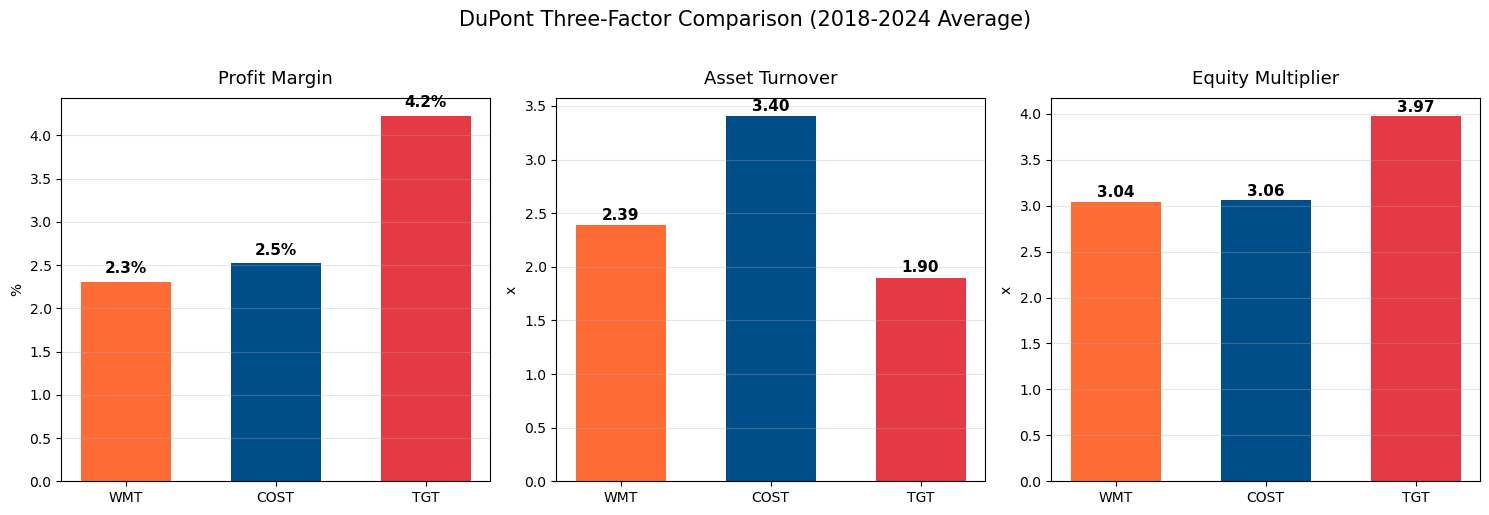

In [21]:
# Prepare data
companies = retail_avg.index.tolist()  # ['WMT', 'COST', 'TGT']
colors = ['#FF6B35', '#004E89', '#E63946']  # WMT orange, COST blue, TGT red

# 1 row x 3 columns subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: Profit Margin
values_pm = (retail_avg['profit_margin'] * 100).values
bars1 = axes[0].bar(companies, values_pm, color=colors, width=0.6)
axes[0].set_title('Profit Margin', fontsize=13, pad=10)
axes[0].set_ylabel('%')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, values_pm):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Subplot 2: Asset Turnover
values_at = retail_avg['asset_turnover'].values
bars2 = axes[1].bar(companies, values_at, color=colors, width=0.6)
axes[1].set_title('Asset Turnover', fontsize=13, pad=10)
axes[1].set_ylabel('x')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, values_at):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Subplot 3: Equity Multiplier
values_em = retail_avg['equity_multiplier'].values
bars3 = axes[2].bar(companies, values_em, color=colors, width=0.6)
axes[2].set_title('Equity Multiplier', fontsize=13, pad=10)
axes[2].set_ylabel('x')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, values_em):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('DuPont Three-Factor Comparison (2018-2024 Average)', fontsize=15, y=1.02)

plt.tight_layout()
plt.show()

### From static averages to dynamic trajectories

The bar chart above shows a single number per factor per company — but those numbers are 7-year averages. What if a company's strategy is evolving? The next three charts show each factor separately over time for all three companies, so we can see whether each "business-model identity" is stable or shifting.

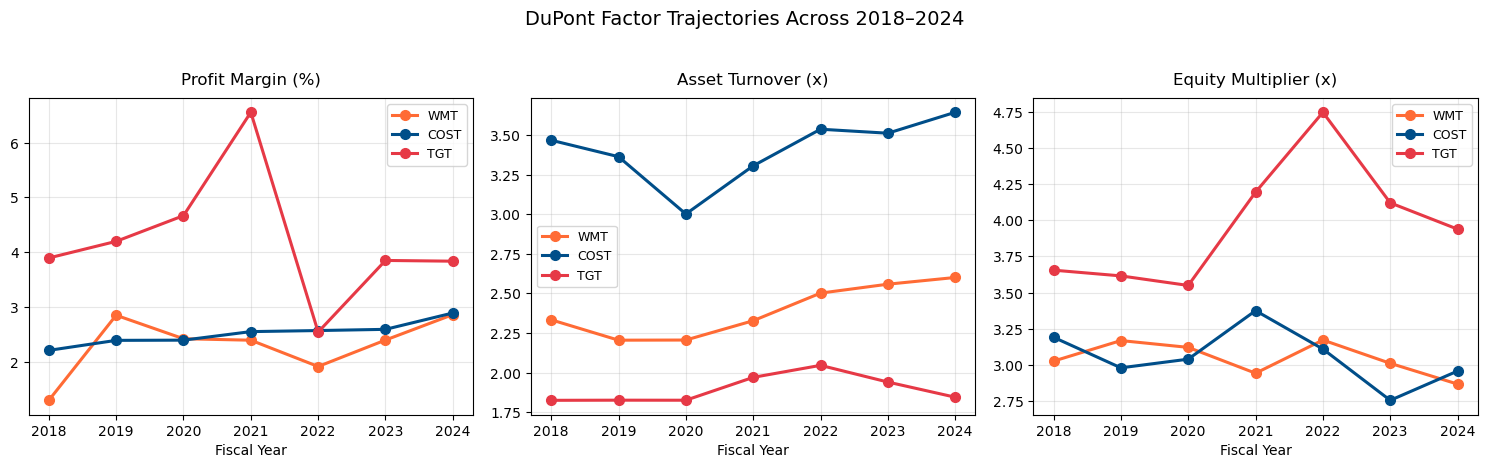

In [22]:
# Chart 5: three factors over time (one subplot per factor)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

colors_dict = {'WMT': '#FF6B35', 'COST': '#004E89', 'TGT': '#E63946'}
factor_specs = [
    ('profit_margin', 'Profit Margin (%)', 100),
    ('asset_turnover', 'Asset Turnover (x)', 1),
    ('equity_multiplier', 'Equity Multiplier (x)', 1),
]

for ax, (col, title, multiplier) in zip(axes, factor_specs):
    for ticker in ['WMT', 'COST', 'TGT']:
        company_data = retail[retail['ticker'] == ticker].sort_values('year')
        ax.plot(company_data['year'], company_data[col] * multiplier,
                marker='o', linewidth=2.2, markersize=7,
                label=ticker, color=colors_dict[ticker])
    ax.set_title(title, fontsize=12, pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    ax.set_xlabel('Fiscal Year')

fig.suptitle('DuPont Factor Trajectories Across 2018\u20132024', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### Putting It Together: The ROE-as-Product View

The three charts above show the differences across the three factors. But the reader (and we ourselves) need a **combined view** that shows "the three factors multiplied equals ROE" as a visual relationship.

The chart below shows all four values — the three factors plus their product — side by side for each company.


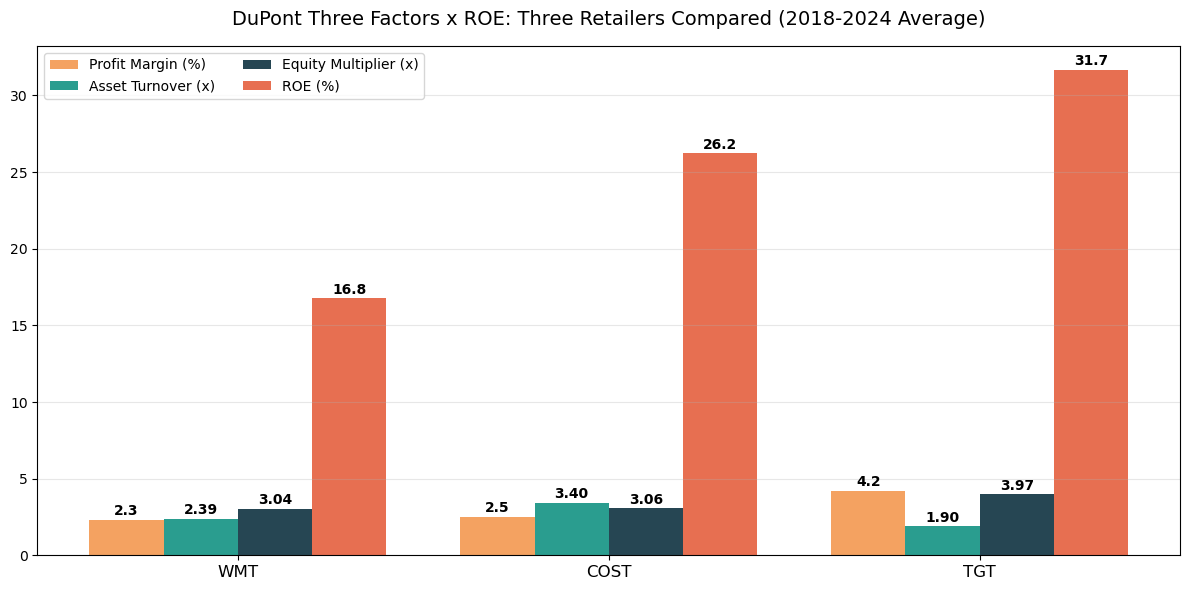


DuPont formula check (three-factor product should equal ROE):
  WMT: 0.023 x 2.39 x 3.04 = 0.168  approx.  0.168 (actual ROE)
  COST: 0.025 x 3.40 x 3.06 = 0.262  approx.  0.262 (actual ROE)
  TGT: 0.042 x 1.90 x 3.97 = 0.318  approx.  0.317 (actual ROE)


In [23]:
# Prepare data
companies = retail_avg.index.tolist()
pm = retail_avg['profit_margin'].values * 100      # Profit margin (%)
at = retail_avg['asset_turnover'].values           # Turnover
em = retail_avg['equity_multiplier'].values        # Equity multiplier
roe = retail_avg['roe'].values * 100               # ROE (%)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(companies))  # positions for the three companies
width = 0.2

# Four grouped bars
bars_pm  = ax.bar(x - width*1.5, pm,  width, label='Profit Margin (%)',   color='#F4A261')
bars_at  = ax.bar(x - width*0.5, at,  width, label='Asset Turnover (x)',  color='#2A9D8F')
bars_em  = ax.bar(x + width*0.5, em,  width, label='Equity Multiplier (x)', color='#264653')
bars_roe = ax.bar(x + width*1.5, roe, width, label='ROE (%)',              color='#E76F51')

for bars, values, fmt in [
    (bars_pm,  pm,  '{:.1f}'),
    (bars_at,  at,  '{:.2f}'),
    (bars_em,  em,  '{:.2f}'),
    (bars_roe, roe, '{:.1f}')
]:
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                fmt.format(val), ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(companies, fontsize=12)
ax.set_title('DuPont Three Factors x ROE: Three Retailers Compared (2018-2024 Average)',
             fontsize=14, pad=15)
ax.legend(loc='upper left', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Also print the math verification so the reader sees the product relationship directly
print()
print('DuPont formula check (three-factor product should equal ROE):')
for i, ticker in enumerate(companies):
    product = pm[i]/100 * at[i] * em[i]   # as a decimal
    actual_roe = roe[i]/100
    print(f'  {ticker}: {pm[i]/100:.3f} x {at[i]:.2f} x {em[i]:.2f} = {product:.3f}  approx.  {actual_roe:.3f} (actual ROE)')



### Attribution: *what drove* the year-over-year ROE changes?

Everything above compares *levels*. But a more analyst-oriented question is: when ROE goes up or down from one year to the next, *which factor caused the change*?

We use an additive attribution. If ROE = PM × AT × EM, then the approximate year-over-year contribution of each factor can be decomposed via log differences. The chart below shows, for each company and each year-to-year transition, how much of the ROE change came from margin vs. turnover vs. leverage.

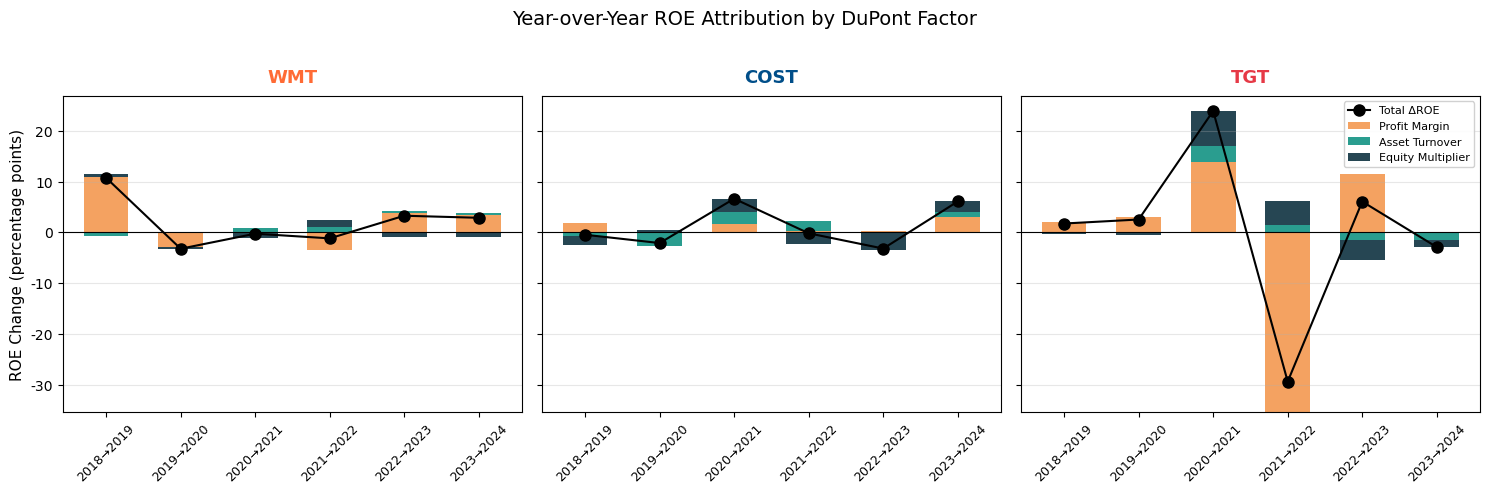

In [24]:
# Chart 6: year-over-year ROE change decomposed into factor contributions
# Using a log-difference approximation: \u0394ln(ROE) \u2248 \u0394ln(PM) + \u0394ln(AT) + \u0394ln(EM)
# We then rescale contributions so they add up to the actual \u0394ROE (in percentage points)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, ticker in zip(axes, ['WMT', 'COST', 'TGT']):
    company_data = retail[retail['ticker'] == ticker].sort_values('year').reset_index(drop=True)

    attribution_records = []
    for i in range(1, len(company_data)):
        prev = company_data.iloc[i-1]
        curr = company_data.iloc[i]

        # Actual ROE change (percentage points)
        delta_roe_pp = (curr['roe'] - prev['roe']) * 100

        # Log changes in each factor
        d_ln_pm = np.log(curr['profit_margin'] / prev['profit_margin'])
        d_ln_at = np.log(curr['asset_turnover'] / prev['asset_turnover'])
        d_ln_em = np.log(curr['equity_multiplier'] / prev['equity_multiplier'])
        d_ln_total = d_ln_pm + d_ln_at + d_ln_em

        # Allocate the actual \u0394ROE proportionally to log contributions
        if abs(d_ln_total) > 1e-9:
            pm_contrib = delta_roe_pp * (d_ln_pm / d_ln_total)
            at_contrib = delta_roe_pp * (d_ln_at / d_ln_total)
            em_contrib = delta_roe_pp * (d_ln_em / d_ln_total)
        else:
            pm_contrib = at_contrib = em_contrib = 0

        attribution_records.append({
            'transition': f"{int(prev['year'])}\u2192{int(curr['year'])}",
            'PM': pm_contrib,
            'AT': at_contrib,
            'EM': em_contrib,
            'total': delta_roe_pp
        })

    attr_df = pd.DataFrame(attribution_records)

    x_positions = np.arange(len(attr_df))
    width = 0.6

    pm_vals = attr_df['PM'].values
    at_vals = attr_df['AT'].values
    em_vals = attr_df['EM'].values

    def stack_positive(vals):
        return np.where(vals > 0, vals, 0)
    def stack_negative(vals):
        return np.where(vals < 0, vals, 0)

    pm_pos, pm_neg = stack_positive(pm_vals), stack_negative(pm_vals)
    at_pos, at_neg = stack_positive(at_vals), stack_negative(at_vals)
    em_pos, em_neg = stack_positive(em_vals), stack_negative(em_vals)

    # Positive side
    ax.bar(x_positions, pm_pos, width, color='#F4A261', label='Profit Margin')
    ax.bar(x_positions, at_pos, width, bottom=pm_pos, color='#2A9D8F', label='Asset Turnover')
    ax.bar(x_positions, em_pos, width, bottom=pm_pos + at_pos, color='#264653', label='Equity Multiplier')

    # Negative side
    ax.bar(x_positions, pm_neg, width, color='#F4A261')
    ax.bar(x_positions, at_neg, width, bottom=pm_neg, color='#2A9D8F')
    ax.bar(x_positions, em_neg, width, bottom=pm_neg + at_neg, color='#264653')

    # Line marker for total \u0394ROE
    ax.plot(x_positions, attr_df['total'], 'ko-', markersize=8, linewidth=1.5,
            label='Total \u0394ROE', zorder=5)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(attr_df['transition'], rotation=45, fontsize=9)
    ax.set_title(f'{ticker}', fontsize=13, pad=10, color=colors_dict[ticker], fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    if ax == axes[0]:
        ax.set_ylabel('ROE Change (percentage points)', fontsize=11)

axes[-1].legend(loc='upper right', fontsize=8, framealpha=0.9)
fig.suptitle('Year-over-Year ROE Attribution by DuPont Factor', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### The "Fingerprints" of Three Business Models

Let's visualize the same differences in another way: **radar charts** (also known as spider charts).

We draw a small radar chart for each company, with three axes: Profit Margin, Asset Turnover, Equity Multiplier. Placing the three charts side by side makes **three different "shapes"** — and these shapes *are* the three different business models, like fingerprints that reveal a company's "type" at a glance.


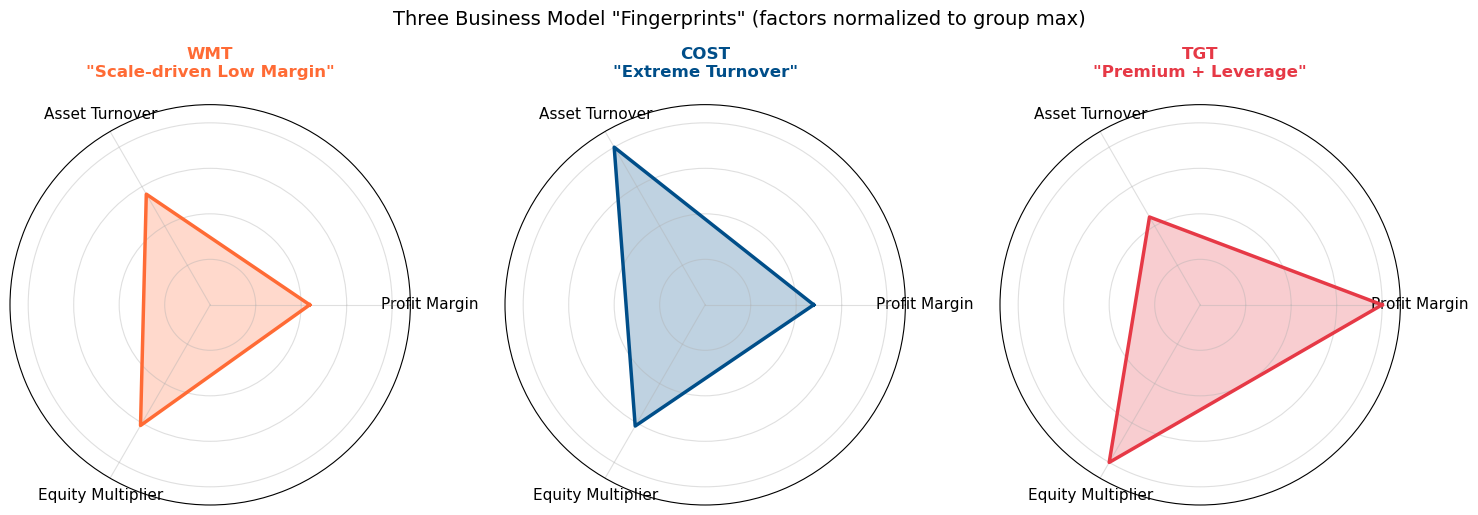

In [25]:
# Normalize each factor to [0, 1] so the three radar charts are directly comparable.
# Normalization: each value / the maximum of that factor across the three companies.
pm_norm = retail_avg['profit_margin'] / retail_avg['profit_margin'].max()
at_norm = retail_avg['asset_turnover'] / retail_avg['asset_turnover'].max()
em_norm = retail_avg['equity_multiplier'] / retail_avg['equity_multiplier'].max()

# Three axes
categories = ['Profit Margin', 'Asset Turnover', 'Equity Multiplier']
num_vars = len(categories)

# Angles, evenly spaced
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

# 1 row x 3 columns, each polar
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          subplot_kw=dict(projection='polar'))

colors = {'WMT': '#FF6B35', 'COST': '#004E89', 'TGT': '#E63946'}
commercial_tags = {
    'WMT':  'Scale-driven Low Margin',
    'COST': 'Extreme Turnover',
    'TGT':  'Premium + Leverage'
}

for i, ticker in enumerate(['WMT', 'COST', 'TGT']):
    values = [pm_norm[ticker], at_norm[ticker], em_norm[ticker]]
    values += values[:1]  # close the polygon

    ax = axes[i]
    ax.plot(angles, values, color=colors[ticker], linewidth=2.5)
    ax.fill(angles, values, color=colors[ticker], alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['', '', '', ''])
    ax.grid(True, alpha=0.4)

    # Subplot title: ticker + business model tag
    ax.set_title(f'{ticker}\n"{commercial_tags[ticker]}"',
                 fontsize=12, pad=20, color=colors[ticker], fontweight='bold')

fig.suptitle('Three Business Model "Fingerprints" (factors normalized to group max)',
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

### A strategic map: where does each company sit on the profit vs. turnover plane?

So far we've looked at the three retailers in isolation. But the question "is Costco's turnover really high?" needs a baseline. Let's plot *all 10 companies* from our dataset on a two-dimensional profit-margin-vs-turnover map, and highlight our three retailers on top. This reveals whether the retail trio occupies a distinct region or overlaps with other industries.

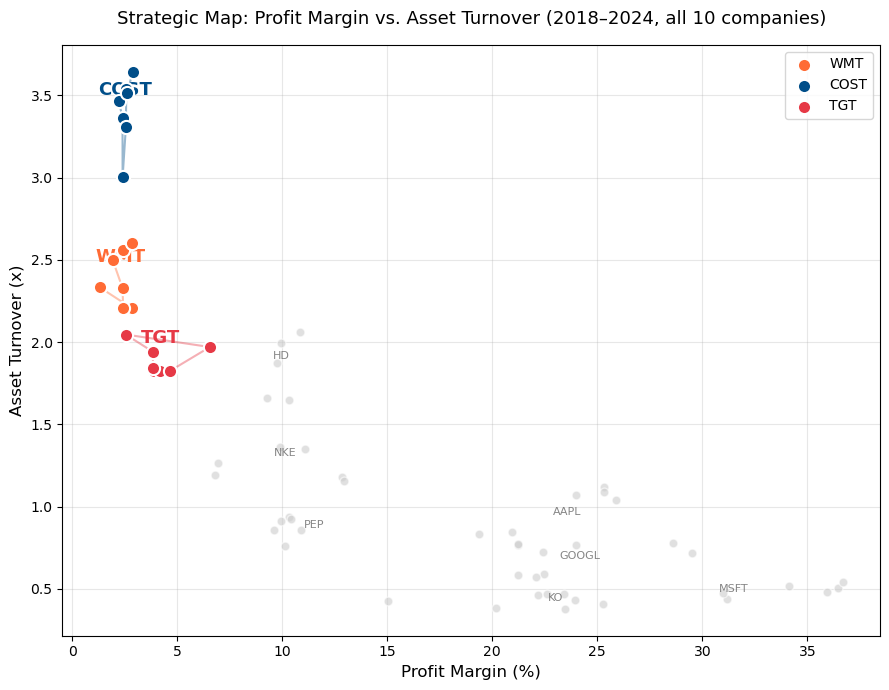


Reading the map:
- Upper-left region (high turnover, low margin): retailers — Costco, Walmart
- Lower-right region (high margin, low turnover): software/tech — Microsoft, Google
- Middle band: Target, Apple, and most others


In [26]:
# Chart 9: profit margin vs asset turnover \u2014 strategic positioning map across all 10 companies

highlight_tickers = {'WMT', 'COST', 'TGT'}
highlight_colors = {'WMT': '#FF6B35', 'COST': '#004E89', 'TGT': '#E63946'}

fig, ax = plt.subplots(figsize=(9, 7))

# Background: all other companies as gray dots
others = data_clean[~data_clean['ticker'].isin(highlight_tickers)]
for ticker in others['ticker'].unique():
    company_data = others[others['ticker'] == ticker].sort_values('year')
    ax.scatter(company_data['profit_margin'] * 100,
               company_data['asset_turnover'],
               s=40, color='#CCCCCC', alpha=0.6, edgecolor='white', zorder=2)
    # Label the cluster centroid
    ax.annotate(ticker,
                xy=(company_data['profit_margin'].mean() * 100, company_data['asset_turnover'].mean()),
                fontsize=8, color='#666666', alpha=0.8, ha='center')

# Foreground: the three retailers with year trajectories
for ticker in ['WMT', 'COST', 'TGT']:
    company_data = data_clean[data_clean['ticker'] == ticker].sort_values('year')
    x_vals = company_data['profit_margin'].values * 100
    y_vals = company_data['asset_turnover'].values

    # Connect years with lines
    ax.plot(x_vals, y_vals, '-', color=highlight_colors[ticker], alpha=0.4, linewidth=1.5, zorder=3)
    # Points
    ax.scatter(x_vals, y_vals, s=90, color=highlight_colors[ticker],
               edgecolor='white', linewidth=1.5, label=ticker, zorder=4)
    # Label the centroid
    ax.annotate(ticker,
                xy=(company_data['profit_margin'].mean() * 100, company_data['asset_turnover'].mean()),
                fontsize=13, color=highlight_colors[ticker], fontweight='bold',
                ha='center', va='center',
                xytext=(0, 15), textcoords='offset points')

ax.set_xlabel('Profit Margin (%)', fontsize=12)
ax.set_ylabel('Asset Turnover (x)', fontsize=12)
ax.set_title('Strategic Map: Profit Margin vs. Asset Turnover (2018\u20132024, all 10 companies)',
             fontsize=13, pad=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print()
print('Reading the map:')
print('- Upper-left region (high turnover, low margin): retailers \u2014 Costco, Walmart')
print('- Lower-right region (high margin, low turnover): software/tech \u2014 Microsoft, Google')
print('- Middle band: Target, Apple, and most others')


### What the Radar Charts Tell Us

The three radar charts make the "business model fingerprints" obvious:

- **WMT has the most "balanced" triangle**: No factor is particularly outstanding, and none is particularly weak. This reflects its stability as a mega-scale retailer — scale effects bring every dimension above industry average, with no need to take any factor to the extreme.
- **COST's triangle stretches toward turnover**, with the other two factors relatively shorter. This is the essence of the membership business model: **concentrate almost all strategic resources on one dimension — turnover efficiency**.
- **TGT's triangle stretches toward profit margin and equity multiplier, with the turnover axis shortest**: a combined "higher prices + more leverage" strategy, while turnover efficiency is the weakest of the three.

**This difference in shape tells us something very important**:

> DuPont decomposition is not just a mathematical exercise — it is a **taxonomy of business models**. Even within a single industry category like "retail," we find meaningfully different "species" along the DuPont axes.

This is exactly why we cannot judge a company by its ROE alone — **the same ROE number can sit on top of completely different companies**.


### Beyond DuPont: short-term liquidity

DuPont tells us how a company generates returns, but not whether it can pay its bills next quarter. The current ratio (current assets ÷ current liabilities) is the simplest short-term-liquidity check. A ratio above 1 means current assets more than cover current liabilities; below 1 means the company is running on tight working capital.

Retailers often run below 1 *deliberately* — they collect cash from customers instantly but pay suppliers on credit, so short-term liabilities can exceed short-term assets without any distress.

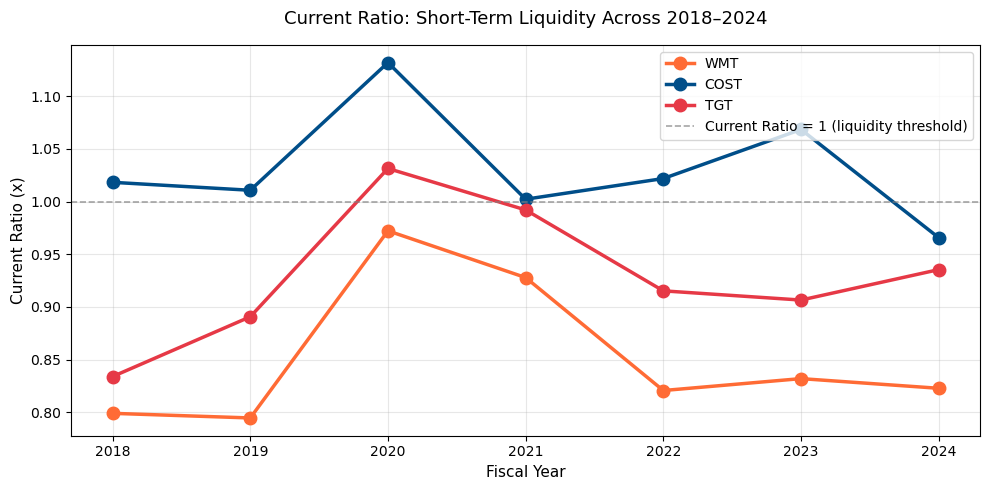


Interpretation:
- All three retailers operate at or below 1.0 most years — typical of the sector.
- WMT and COST have the tightest current ratios (efficient working capital).
- TGT sits slightly higher — some excess short-term assets, consistent with its differentiated positioning.


In [27]:
# Chart 10: current ratio comparison across the three retailers over 2018\u20132024
fig, ax = plt.subplots(figsize=(10, 5))

for ticker in ['WMT', 'COST', 'TGT']:
    company_data = retail[retail['ticker'] == ticker].sort_values('year')
    ax.plot(company_data['year'], company_data['current_ratio'],
            marker='o', linewidth=2.5, markersize=9,
            label=ticker, color=colors_dict[ticker])

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Current Ratio = 1 (liquidity threshold)')

ax.set_title('Current Ratio: Short-Term Liquidity Across 2018\u20132024', fontsize=13, pad=15)
ax.set_xlabel('Fiscal Year', fontsize=11)
ax.set_ylabel('Current Ratio (x)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print('Interpretation:')
print('- All three retailers operate at or below 1.0 most years \u2014 typical of the sector.')
print('- WMT and COST have the tightest current ratios (efficient working capital).')
print('- TGT sits slightly higher \u2014 some excess short-term assets, consistent with its differentiated positioning.')

## Automatic Insight Generation: Writing an Analysis for Any Company Selection

We have now manually analyzed the differences among WMT, COST, and TGT. But the final users of this tool are **business students who pick arbitrary company combinations** — they might choose Apple vs. Microsoft, or Coca-Cola vs. PepsiCo. **We cannot hand-write an analysis for every possible combination.**

So we need a function that **automatically generates textual insight**: given the DuPont data for a handful of companies, output a coherent business commentary.

### Design approach: rule-based templates + data facts

We **intentionally avoid calling an LLM** to generate the text. Three reasons:

1. **Explainability**: As students (and as authors), we must be able to explain every sentence the tool produces. LLM output is not traceable to specific rules.
2. **Deployment simplicity**: Streamlit Community Cloud does not require API keys for a rule-based approach to work.
3. **Output stability**: Given the same data, the tool always returns the same conclusion — no stochastic drift.

### Rule design

For each company:
1. Find the "relative champion" among the three factors (which factor is strongest compared to its peers in the same selection)
2. Tag the company by its champion factor:
   - Profit margin champion -> "Premium"
   - Turnover champion -> "Efficiency"
   - Equity multiplier champion -> "Leverage"
3. Identify pairs of companies where ROE values are close but the structures differ; highlight these specially.

Then plug the identified patterns into natural-language templates to produce a coherent paragraph.


In [28]:
def identify_dominant_factor(dupont_table, ticker):
    """
    Given a company, identify which of its DuPont factors is strongest
    relative to the other companies in the same table.

    Returns a string label: 'Premium' / 'Efficiency' / 'Leverage'
    """
    # Normalize each factor to [0, 1]
    # (each company's factor / the max of that factor across the group)
    pm_norm = dupont_table['profit_margin']     / dupont_table['profit_margin'].max()
    at_norm = dupont_table['asset_turnover']    / dupont_table['asset_turnover'].max()
    em_norm = dupont_table['equity_multiplier'] / dupont_table['equity_multiplier'].max()

    # This company's three normalized values
    factors = {
        'Profit Margin':     pm_norm[ticker],
        'Asset Turnover':    at_norm[ticker],
        'Equity Multiplier': em_norm[ticker]
    }

    # Strongest factor
    dominant = max(factors, key=factors.get)

    # Map to a business-model tag
    tag_map = {
        'Profit Margin':     'Premium',
        'Asset Turnover':    'Efficiency',
        'Equity Multiplier': 'Leverage'
    }

    return tag_map[dominant], dominant


def generate_insights(dupont_table):
    """
    Given a DuPont table (index = ticker, columns include profit_margin /
    asset_turnover / equity_multiplier / roe), produce an English business commentary.
    """
    tickers = dupont_table.index.tolist()
    lines = []

    # Opening: ROE ranking
    roe_ranked = dupont_table['roe'].sort_values(ascending=False)
    top_company = roe_ranked.index[0]
    top_roe = roe_ranked.iloc[0] * 100
    bottom_company = roe_ranked.index[-1]
    bottom_roe = roe_ranked.iloc[-1] * 100

    lines.append(
        f'Among the {len(tickers)} selected companies, **{top_company}** has the highest ROE '
        f'({top_roe:.1f}%), while **{bottom_company}** has the lowest ({bottom_roe:.1f}%).'
    )
    lines.append('But ROE is only the result — the DuPont decomposition tells us *how* each company got there.\n')

    # Per-company qualitative tag
    lines.append('### DuPont characteristics by company\n')
    for ticker in tickers:
        tag, factor_name = identify_dominant_factor(dupont_table, ticker)
        pm = dupont_table.loc[ticker, 'profit_margin'] * 100
        at = dupont_table.loc[ticker, 'asset_turnover']
        em = dupont_table.loc[ticker, 'equity_multiplier']
        roe_pct = dupont_table.loc[ticker, 'roe'] * 100

        lines.append(
            f'- **{ticker} ({tag})**: '
            f'Profit Margin {pm:.1f}%, Turnover {at:.2f}, Equity Multiplier {em:.2f} -> '
            f'ROE = {roe_pct:.1f}%. The primary driver of this company\'s ROE is **{factor_name}**.'
        )

    # Identify pairs: close ROE but different drivers
    lines.append('\n### Key insight\n')

    roe_values = dupont_table['roe']
    similar_pairs = []
    for i, t1 in enumerate(tickers):
        for t2 in tickers[i+1:]:
            roe_diff_pct = abs(roe_values[t1] - roe_values[t2]) / max(abs(roe_values[t1]), abs(roe_values[t2]))
            if roe_diff_pct < 0.20:
                tag1, f1 = identify_dominant_factor(dupont_table, t1)
                tag2, f2 = identify_dominant_factor(dupont_table, t2)
                if f1 != f2:
                    similar_pairs.append((t1, t2, f1, f2))

    if similar_pairs:
        for t1, t2, f1, f2 in similar_pairs:
            lines.append(
                f'- **{t1} and {t2} have similar ROE but completely different drivers**: '
                f'{t1} relies on **{f1}**, while {t2} relies on **{f2}**. '
                f'This is precisely the classic DuPont scenario — the same return on equity '
                f'can sit on top of fundamentally different business models.'
            )
    else:
        lines.append('- The selected companies have meaningfully different ROE levels, reflecting broad differences in scale and strategy.')

    return '\n'.join(lines)


# Test: generate insights for WMT / COST / TGT
retail_dupont_avg = retail_avg[['profit_margin', 'asset_turnover', 'equity_multiplier', 'roe']]
insight_text = generate_insights(retail_dupont_avg)
print(insight_text)

Among the 3 selected companies, **TGT** has the highest ROE (31.7%), while **WMT** has the lowest (16.8%).
But ROE is only the result — the DuPont decomposition tells us *how* each company got there.

### DuPont characteristics by company

- **WMT (Leverage)**: Profit Margin 2.3%, Turnover 2.39, Equity Multiplier 3.04 -> ROE = 16.8%. The primary driver of this company's ROE is **Equity Multiplier**.
- **COST (Efficiency)**: Profit Margin 2.5%, Turnover 3.40, Equity Multiplier 3.06 -> ROE = 26.2%. The primary driver of this company's ROE is **Asset Turnover**.
- **TGT (Premium)**: Profit Margin 4.2%, Turnover 1.90, Equity Multiplier 3.97 -> ROE = 31.7%. The primary driver of this company's ROE is **Profit Margin**.

### Key insight

- **COST and TGT have similar ROE but completely different drivers**: COST relies on **Asset Turnover**, while TGT relies on **Profit Margin**. This is precisely the classic DuPont scenario — the same return on equity can sit on top of fundamentally differen

In [29]:
def identify_dominant_factor(dupont_table, ticker, threshold=0.85):
    """
    Improved version: determine a company's DuPont characteristic type.

    A factor is considered "dominant" only if its normalized value >= threshold.
    If no factor reaches the threshold, the company is tagged "Balanced".
    """
    pm_norm = dupont_table['profit_margin']     / dupont_table['profit_margin'].max()
    at_norm = dupont_table['asset_turnover']    / dupont_table['asset_turnover'].max()
    em_norm = dupont_table['equity_multiplier'] / dupont_table['equity_multiplier'].max()

    factors = {
        'Profit Margin':     pm_norm[ticker],
        'Asset Turnover':    at_norm[ticker],
        'Equity Multiplier': em_norm[ticker]
    }

    dominant_factor = max(factors, key=factors.get)
    dominant_value = factors[dominant_factor]

    # If even the strongest factor does not clear the threshold, call it Balanced
    if dominant_value < threshold:
        return 'Balanced', None

    tag_map = {
        'Profit Margin':     'Premium',
        'Asset Turnover':    'Efficiency',
        'Equity Multiplier': 'Leverage'
    }

    return tag_map[dominant_factor], dominant_factor


def generate_insights(dupont_table):
    """
    Given a DuPont table, produce an English business commentary.
    """
    tickers = dupont_table.index.tolist()
    lines = []

    roe_ranked = dupont_table['roe'].sort_values(ascending=False)
    top_company = roe_ranked.index[0]
    top_roe = roe_ranked.iloc[0] * 100
    bottom_company = roe_ranked.index[-1]
    bottom_roe = roe_ranked.iloc[-1] * 100

    lines.append(
        f'Among the {len(tickers)} selected companies, **{top_company}** has the highest ROE '
        f'({top_roe:.1f}%), while **{bottom_company}** has the lowest ({bottom_roe:.1f}%).'
    )
    lines.append('But ROE is only the result — the DuPont decomposition tells us *how* each company got there.\n')

    lines.append('### DuPont characteristics by company\n')
    for ticker in tickers:
        tag, factor_name = identify_dominant_factor(dupont_table, ticker)
        pm = dupont_table.loc[ticker, 'profit_margin'] * 100
        at = dupont_table.loc[ticker, 'asset_turnover']
        em = dupont_table.loc[ticker, 'equity_multiplier']
        roe_pct = dupont_table.loc[ticker, 'roe'] * 100

        if factor_name is None:
            # Balanced type
            lines.append(
                f'- **{ticker} ({tag})**: '
                f'Profit Margin {pm:.1f}%, Turnover {at:.2f}, Equity Multiplier {em:.2f} -> '
                f'ROE = {roe_pct:.1f}%. The three factors are relatively balanced, with no single dominant driver.'
            )
        else:
            lines.append(
                f'- **{ticker} ({tag})**: '
                f'Profit Margin {pm:.1f}%, Turnover {at:.2f}, Equity Multiplier {em:.2f} -> '
                f'ROE = {roe_pct:.1f}%. The primary driver of this company\'s ROE is **{factor_name}**.'
            )

    lines.append('\n### Key insight\n')

    roe_values = dupont_table['roe']
    similar_pairs = []
    for i, t1 in enumerate(tickers):
        for t2 in tickers[i+1:]:
            roe_diff_pct = abs(roe_values[t1] - roe_values[t2]) / max(abs(roe_values[t1]), abs(roe_values[t2]))
            if roe_diff_pct < 0.20:
                tag1, f1 = identify_dominant_factor(dupont_table, t1)
                tag2, f2 = identify_dominant_factor(dupont_table, t2)
                # Only flag as a classic DuPont scenario if both have clear dominant factors AND the factors differ
                if f1 is not None and f2 is not None and f1 != f2:
                    similar_pairs.append((t1, t2, f1, f2))

    if similar_pairs:
        for t1, t2, f1, f2 in similar_pairs:
            lines.append(
                f'- **{t1} and {t2} have similar ROE but completely different drivers**: '
                f'{t1} relies on **{f1}**, while {t2} relies on **{f2}**. '
                f'This is precisely the classic DuPont scenario — the same return on equity '
                f'can sit on top of fundamentally different business models.'
            )
    else:
        lines.append('- The selected companies either have meaningfully different ROE levels, or similar drivers across the group, '
                     'so no "similar ROE but different structure" pairs emerge.')

    return '\n'.join(lines)


# Re-run on WMT / COST / TGT to see the improved output
insight_text = generate_insights(retail_dupont_avg)
print(insight_text)


Among the 3 selected companies, **TGT** has the highest ROE (31.7%), while **WMT** has the lowest (16.8%).
But ROE is only the result — the DuPont decomposition tells us *how* each company got there.

### DuPont characteristics by company

- **WMT (Balanced)**: Profit Margin 2.3%, Turnover 2.39, Equity Multiplier 3.04 -> ROE = 16.8%. The three factors are relatively balanced, with no single dominant driver.
- **COST (Efficiency)**: Profit Margin 2.5%, Turnover 3.40, Equity Multiplier 3.06 -> ROE = 26.2%. The primary driver of this company's ROE is **Asset Turnover**.
- **TGT (Premium)**: Profit Margin 4.2%, Turnover 1.90, Equity Multiplier 3.97 -> ROE = 31.7%. The primary driver of this company's ROE is **Profit Margin**.

### Key insight

- **COST and TGT have similar ROE but completely different drivers**: COST relies on **Asset Turnover**, while TGT relies on **Profit Margin**. This is precisely the classic DuPont scenario — the same return on equity can sit on top of fundamentally 

## Conclusions and Next Steps

### What we verified

Through the DuPont decomposition of the big three U.S. retailers (WMT / COST / TGT) across 7 fiscal years (2018-2024), **the textbook formula holds exactly on real data** — `ROE = Profit Margin x Asset Turnover x Equity Multiplier` is satisfied for every company in every year, with only floating-point-level residual error (`1e-15` magnitude).

### What we found

The most important finding: **three U.S. retail giants use three completely different "recipes" to generate shareholder returns**.

- **Costco**: Profit margin only 2.5% (nearly identical to Walmart's), but asset turnover reaches 3.4x — generating 26% ROE through **extreme turnover efficiency**.
- **Target**: Profit margin 4.2% (the highest of the three), combined with an equity multiplier of 3.97 — generating 32% ROE through **premium pricing plus leverage**.
- **Walmart**: None of its factors is outstanding, but none is weak; as the world's largest retailer it maintains a stable 17% ROE.

This is the core value of DuPont decomposition — **it is not just a mathematical exercise, it is a taxonomy of business models**.

### Why this analysis matters

If we only looked at ROE, we would easily conclude "TGT is the best and WMT is the worst." But DuPont shows us that the three companies are pursuing completely different strategies in the same retail market, and **"best" and "worst" are the wrong question**. The real question is: **is this business model sustainable?**

Costco's high turnover depends on member stickiness — it collapses if renewal rates drop. Target's high leverage amplifies risk during rising-interest-rate environments. Walmart's scale advantage is no longer a moat in the e-commerce era. **Every model has its own vulnerability**, and deeper analysis would need to bring in industry research, macro environment, and more — which is beyond the scope of this assignment.

### Outputs of this notebook

- Cleaned financial data (saved as `company_financials.csv`, reused by the Streamlit tool)
- Core analysis functions (`identify_dominant_factor`, `generate_insights`), reused by `app.py`
- Visualizations (ROE time series, three-factor comparison, DuPont composite, business-model radar)

### Next step

Building on the notebook's analytical outputs, we construct a Streamlit interactive tool (`app.py`) that lets users select any combination of companies and immediately get a similar DuPont comparison. This extends the value of the tool from "I now understand these three retailers" to "I can help any student understand any combination of companies."
